Prvých 10 simulácií:
   Simulation    p_fair  p_rounded_hacked  p_hacked
0           1  0.150585          0.150585     False
1           2  0.072059          0.072059     False
2           3  0.141582          0.141582     False
3           4  0.598793          0.598793     False
4           5  0.502224          0.502224     False
5           6  0.019373          0.019373     False
6           7  0.120620          0.120620     False
7           8  0.471487          0.471487     False
8           9  0.107135          0.107135     False
9          10  0.404391          0.404391     False

Simulácie, kde sa p stala signifikantná iba kvôli zaokrúhľovaniu:
    Simulation    p_fair  p_rounded_hacked  p_hacked
26          27  0.050988              0.05      True
44          45  0.051642              0.05      True
65          66  0.054572              0.05      True
76          77  0.051489              0.05      True


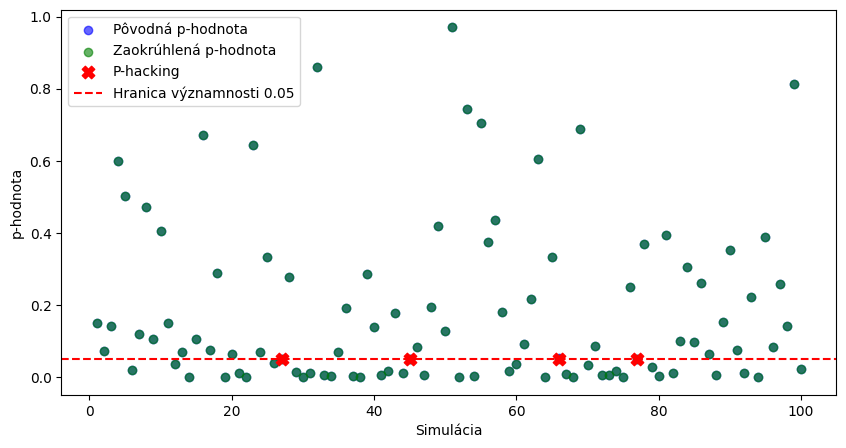

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import sys
import os
sys.path.append(os.path.abspath(".."))
import settings

# nacitanie suborov
def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)

data = merge_files(bmx, demo)
data['gender_label'] = data['RIAGENDR'].map({1: "Men", 2: "Women"})

# parametre simulacie
dependent_var = 'BMXBMI'
sample_size = 400
n_sim = 100
alpha = 0.05  
k = 2         # desatinné miesta pre zaokrúhlenie

# simulacia 
results = []

for sim in range(n_sim):
    sample = data.groupby('gender_label').sample(sample_size, random_state=sim)
    men = sample[sample['gender_label']=='Men'][dependent_var].copy()
    women = sample[sample['gender_label']=='Women'][dependent_var].copy()

    # t-test 
    if len(men) > 1 and len(women) > 1:
        _, p_val = stats.ttest_ind(men, women, nan_policy='omit')
    else:
        p_val = np.nan

    # nesprávne zaokrúhľovanie na 2 desatinné miesta
    p_rounded = round(p_val, k) if (p_val > alpha and round(p_val, k) <= alpha) else p_val

    # indikátor p-hackingu
    p_hacked = (p_val > alpha) and (p_rounded <= alpha)

    results.append({
        "Simulation": sim+1,
        "p_fair": p_val,
        "p_rounded_hacked": p_rounded,
        "p_hacked": p_hacked
    })

df = pd.DataFrame(results)

# výpis tabuľky prvých 10 simulácií
print("Prvých 10 simulácií:")
print(df.head(10))

# Tabuľka hacknutých simuláci
df_hacked = df[df['p_hacked']].copy()
print("\nSimulácie, kde sa p stala signifikantná iba kvôli zaokrúhľovaniu:")
print(df_hacked[['Simulation','p_fair','p_rounded_hacked','p_hacked']])

# graf
plt.figure(figsize=(10,5))

# Pôvodné p-hodnoty
plt.scatter(df['Simulation'], df['p_fair'], alpha=0.6, label='Pôvodná p-hodnota', color='blue')

# Zaokrúhlené p-hodnoty
plt.scatter(df['Simulation'], df['p_rounded_hacked'], alpha=0.6, label='Zaokrúhlená p-hodnota', color='green')

# Hacknuté body 
plt.scatter(df_hacked['Simulation'],
            df_hacked['p_rounded_hacked'],
            color='red', s=80, label='P-hacking', marker='X')

plt.axhline(alpha, color='red', linestyle='--', label='Hranica významnosti 0.05')
plt.xlabel('Simulácia')
plt.ylabel('p-hodnota')
plt.legend()
plt.savefig("phacking_rounding.png",dpi=300)
plt.show()